In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.activations import relu,softmax
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout,BatchNormalization,GlobalAveragePooling2D
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [2]:
(x_train,y_train),(x_test,y_test) = cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 1542s 9us/step


In [3]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


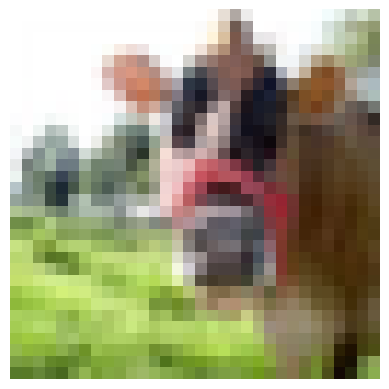

In [4]:
plt.imshow(x_train[0])
plt.axis('off')
plt.show()

In [5]:
print(y_train[0])

[19]


In [17]:
fine_labels = [
    "apple","aquarium_fish","baby","bear","beaver",
    "bed","bee","beetle","bicycle","bottle",
    "bowl","boy","bridge","bus","butterfly",
    "camel","can","castle","caterpillar","cattle",
    "chair","chimpanzee","clock","cloud","cockroach",
    "couch","crab","crocodile","cup","dinosaur",
    "dolphin","elephant","flatfish","forest","fox",
    "girl","hamster","house","kangaroo","keyboard",
    "lamp","lawn_mower","leopard","lion","lizard",
    "lobster","man","maple_tree","motorcycle","mountain",
    "mouse","mushroom","oak_tree","orange","orchid",
    "otter","palm_tree","pear","pickup_truck","pine_tree",
    "plain","plate","poppy","porcupine","possum",
    "rabbit","raccoon","ray","road","rocket",
    "rose","sea","seal","shark","shrew",
    "skunk","skyscraper","snail","snake","spider",
    "squirrel","streetcar","sunflower","sweet_pepper","table",
    "tank","telephone","television","tiger","tractor",
    "train","trout","tulip","turtle","wardrobe",
    "whale","willow_tree","wolf","woman","worm"
]
print(fine_labels[y_train[0][0]])

cattle


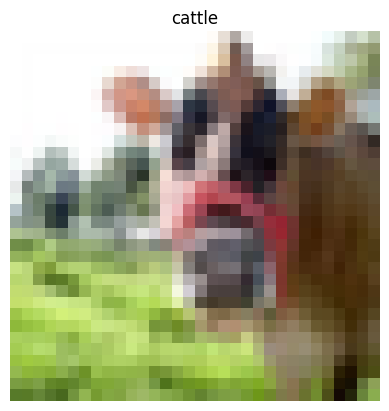

In [7]:
plt.imshow(x_train[0])
plt.title(fine_labels[y_train[0][0]])
plt.axis('off')
plt.show()

In [8]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [9]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [10]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)
#It will works as one hot encoding

In [11]:
'''| Label Format           | Example       | Loss Function                     |
| ---------------------- | ------------- | --------------------------------- |
| Integer labels         | `2`           | `sparse_categorical_crossentropy` |
| One-hot encoded labels | `[0,0,1,0,0]` | `categorical_crossentropy`        |'''


'| Label Format           | Example       | Loss Function                     |\n| ---------------------- | ------------- | --------------------------------- |\n| Integer labels         | `2`           | `sparse_categorical_crossentropy` |\n| One-hot encoded labels | `[0,0,1,0,0]` | `categorical_crossentropy`        |'

In [12]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train)

model = Sequential([


    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),


    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.30),


    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.40),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(100, activation='softmax')
])
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),epochs = 100,callbacks = [early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 50ms/step - accuracy: 0.0283 - loss: 4.5009
Epoch 2/100
  3/782 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.0512 - loss: 4.2442

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.0516 - loss: 4.2008
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.0712 - loss: 4.0415
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.0902 - loss: 3.9015
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.1132 - loss: 3.7546
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.1417 - loss: 3.5891
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.1747 - loss: 3.3953
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.2069 - loss: 3.2308
Epoch 9/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.2386 - loss: 3.0571
Epoch 10/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.2624 - loss: 2.9492
Epoch 11/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.2825 - loss: 2.8293
Epoch 12/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.3010 - loss: 2.7275
Epoch 13/100
782/782 ━━━━━━━━━

In [6]:
#its taking too much time to train, thats why we use Transfer Learnign for faster response
#Transfer Learning is using a pre-made model which is already trained and learning that model a new thing..which is more faster learning rather than learning from scrach
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
(X_train, y_train), (X_test, y_test) = cifar100.load_data()


In [7]:
# Define a preprocessing function to resize images
def resize_images(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

# Assuming a batch size, which will be used when feeding to the model
BATCH_SIZE = 32 # This can be adjusted based on GPU memory

# Create tf.data.Dataset objects for training and testing
# X_train and y_train are already loaded and normalized from a previous cell.
# X_test and y_test are also loaded and normalized.

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(resize_images, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# The direct resizing of entire X_train and X_test arrays caused a ResourceExhaustedError (Out of Memory).
# By converting to tf.data.Dataset, we avoid loading the entire resized dataset into memory at once.
# Note: The model.fit call in the next cell (cell 11bf273d-8b83-499c-bba3-4a7216bd7261)
# will need to be updated to use these dataset objects: e.g., model.fit(train_ds, epochs=10, validation_data=test_ds)

In [9]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = EfficientNetB0(
    weights = "imagenet",#Downloads pretrained ImageNet weights
    include_top = False,#Removes the original ImageNet classifier,Keeps only the feature extractor.
    input_shape = (224,224,3)#
)

base_model.trainable = False
'''EfficientNet

        ↓

Do NOT change its learned weights

        ↓

Only train the new classifier'''


#This makes training much faster and helps preserve the useful features learned from ImageNet.p

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(100,activation = 'softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, # Use the training dataset
    validation_data=test_ds, # Use the testing dataset for validation
    epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 124s 62ms/step - accuracy: 0.5121 - loss: 1.8526 - val_accuracy: 0.6700 - val_loss: 1.1348
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.6204 - loss: 1.3457 - val_accuracy: 0.6958 - val_loss: 1.0512
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 48ms/step - accuracy: 0.6501 - loss: 1.2254 - val_accuracy: 0.7069 - val_loss: 1.0107
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.6670 - loss: 1.1508 - val_accuracy: 0.7064 - val_loss: 0.9961
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6782 - loss: 1.1076 - val_accuracy: 0.7136 - val_loss: 0.9820
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.6928 - loss: 1.0493 - val_accuracy: 0.7173 - val_loss: 0.9772
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.6994 - loss: 1.0185 - val_accuracy: 0.7209 - val_loss: 0.9739
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7121 

In [10]:
model.evaluate(test_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.7196 - loss: 0.9823


[0.9823399186134338, 0.7196000218391418]

In [11]:
predictions = model.predict(test_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step


In [12]:
predicted_labels = np.argmax(predictions,axis = 1)

In [15]:
print("Predicted:")
print(predicted_labels[:10])
print("Actual:")
y_test = np.array(y_test).reshape(-1)
print(y_test[:10])

Predicted:
[68 33 30 51 71 54 31 75 71  0]
Actual:
[49 33 72 51 71 92 15 14 23  0]


In [20]:
print(classification_report(y_test,predicted_labels))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92       100
           1       0.68      0.91      0.78       100
           2       0.67      0.63      0.65       100
           3       0.61      0.60      0.60       100
           4       0.48      0.60      0.53       100
           5       0.76      0.68      0.72       100
           6       0.79      0.82      0.80       100
           7       0.81      0.67      0.73       100
           8       0.88      0.80      0.84       100
           9       0.85      0.90      0.87       100
          10       0.69      0.68      0.69       100
          11       0.40      0.61      0.48       100
          12       0.79      0.77      0.78       100
          13       0.62      0.67      0.64       100
          14       0.67      0.73      0.70       100
          15       0.71      0.85      0.77       100
          16       0.88      0.84      0.86       100
          17       0.92    